# 1. Setup & Environment

Phần này khởi tạo môi trường, cài đặt thư viện và định nghĩa các hàm hỗ trợ trực quan hóa (Visualization).

## 1.1. Cài đặt và Import thư viện

In [1]:
!pip install mediapipe
!wget -q https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 69.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 9.6 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.29.0 which is incompatible.


In [2]:
!pip list | grep mediapipe

mediapipe                                0.10.32


In [3]:
import os
import cv2
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# MediaPipe & Tasks API
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# Deep Learning (TensorFlow/Keras)
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Sklearn Metrics & Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Config hiển thị
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

2026-02-05 07:56:10.563669: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770278170.766699      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770278170.832799      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770278171.335171      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770278171.335224      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770278171.335227      24 computation_placer.cc:177] computation placer alr

## 1.2. Định nghĩa hàm vẽ Landmarks (Custom)

Hàm này giúp vẽ các khớp tay với màu sắc riêng biệt cho từng ngón để dễ quan sát.

In [4]:
def to_pixel(x_norm: float, y_norm: float, w: int, h: int) -> tuple[int, int]:
    x = min(max(x_norm, 0.0), 1.0)
    y = min(max(y_norm, 0.0), 1.0)
    return int(x * w), int(y * h)

def draw_landmarks_on_image_new(rgb_image, detection_result):
    """Vẽ landmarks với màu sắc riêng cho từng ngón tay."""
    hand_landmarks_list = detection_result.hand_landmarks
    annotated_image = np.copy(rgb_image)
    h, w = annotated_image.shape[:2]

    # Định nghĩa các đốt ngón tay
    fingers_connections = {
        "thumb":  [(0, 1), (1, 2), (2, 3), (3, 4)],
        "index":  [(0, 5), (5, 6), (6, 7), (7, 8)],
        "middle": [(0, 9), (9, 10), (10, 11), (11, 12)],
        "ring":   [(0, 13), (13, 14), (14, 15), (15, 16)],
        "pinky":  [(0, 17), (17, 18), (18, 19), (19, 20)]
    }

    # Màu sắc (RGB)
    finger_colors = {
        "thumb":  (255, 0, 0),    # Đỏ
        "index":  (0, 255, 0),    # Xanh lá
        "middle": (0, 0, 255),    # Xanh dương
        "ring":   (255, 255, 0),  # Vàng
        "pinky":  (255, 0, 255)   # Tím
    }

    if hand_landmarks_list:
        for hand_landmarks in hand_landmarks_list:
            pts = [to_pixel(lm.x, lm.y, w, h) for lm in hand_landmarks]
            
            # Vẽ đường nối
            for finger, connections in fingers_connections.items():
                color = finger_colors[finger]
                for idx_a, idx_b in connections:
                    cv2.line(annotated_image, pts[idx_a], pts[idx_b], color, 2)
            
            # Vẽ điểm khớp
            for (x, y) in pts:
                cv2.circle(annotated_image, (x, y), 3, (255, 255, 255), -1)
                cv2.circle(annotated_image, (x, y), 4, (0, 0, 0), 1)

    return annotated_image

# 2. Data Processing

## 2.1. Giải thích tham số & Cấu hình

Trước khi xử lý, ta thiết lập các tham số quan trọng cho MediaPipe:

    num_hands = 1: Chỉ định detector tập trung tìm kiếm đúng 1 bàn tay trong khung hình. Giúp giảm nhiễu nền.

    min_hand_detection_confidence = 0.3: Ngưỡng tin cậy thấp (30%) giúp bắt được các bàn tay bị mờ, bị che khuất một phần hoặc ở góc khó trong tập dữ liệu đa dạng.

    Input Vector (42): Dữ liệu đầu vào cho mô hình là vector 1 chiều gồm 42 giá trị thực (21 landmarks × 2 tọa độ x,y).

In [5]:
# Đường dẫn dữ liệu
DATA_DIR = '/kaggle/input/aslamerican-sign-language-aplhabet-dataset/ASL_Alphabet_Dataset/asl_alphabet_train'
DATA_PICKLE_PATH = '/kaggle/input/data-pickle/data.pickle'

# Cờ kiểm soát: False = Luôn chạy lại xử lý để kiểm chứng dữ liệu mới
SKIP_PROCESSING = False

## 2.2. Trích xuất đặc trưng (Main Processing)

Đoạn code này thực hiện quét toàn bộ thư mục, detect landmark và lưu lại các mẫu (Sample) để kiểm tra.

In [6]:
from tqdm.notebook import tqdm
import os
import time
import cv2
import mediapipe as mp
import numpy as np
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

if not SKIP_PROCESSING:
    print("Dang khoi chay quy trinh xu ly du lieu (Feature Extraction)...")
    
    # Cau hinh MediaPipe Detector
    base_options = python.BaseOptions(model_asset_path='hand_landmarker.task')
    options = vision.HandLandmarkerOptions(
        base_options=base_options,
        num_hands=1,
        min_hand_detection_confidence=0.3
    )
    detector = vision.HandLandmarker.create_from_options(options)

    data = []
    labels = []
    
    # List luu mau de visualize
    debug_samples = [] 
    target_viz_indices = np.linspace(0, 3000, 20, dtype=int)
    total_count = 0
    
    # Bien dem tong thoi gian
    global_start = time.time()

    # Lay danh sach cac thu muc class
    # Neu muon chay tat ca cac folder thi bo [:3]
    class_dirs = sorted(os.listdir(DATA_DIR))
    
    # 1. Vong lap qua tung thu muc (Class)
    for dir_ in class_dirs:
        dir_path = os.path.join(DATA_DIR, dir_)
        if not os.path.isdir(dir_path): continue

        # Lay danh sach anh
        all_images = os.listdir(dir_path)
        
        # --- QUAN TRONG: Chi lay 3 anh dau tien cua moi folder ---
        image_files = all_images
        
        # Bat dau do thoi gian cho folder nay
        folder_start_time = time.time()
        folder_count = 0
        
        # 2. Vong lap qua cac file anh (da duoc gioi han so luong)
        for img_path in tqdm(image_files, desc=f"Processing '{dir_}'", leave=False):
            img_full_path = os.path.join(dir_path, img_path)
            
            raw_img = cv2.imread(img_full_path)
            if raw_img is None: continue
            
            img_rgb = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
            
            # Detect Landmark
            detection_result = detector.detect(mp_image)

            if detection_result.hand_landmarks:
                hand_landmarks = detection_result.hand_landmarks[0]
                data_aux = []
                for lm in hand_landmarks:
                    data_aux.append(lm.x)
                    data_aux.append(lm.y)

                if len(data_aux) == 42:
                    data.append(data_aux)
                    labels.append(dir_)
                    folder_count += 1
                    
                    # Luu mau kiem tra
                    if total_count in target_viz_indices or len(debug_samples) < 20:
                        if len(debug_samples) < 20:
                            debug_samples.append({
                                'img_rgb': img_rgb,
                                'result': detection_result,
                                'label': dir_
                            })
                    total_count += 1
        
        # Ket thuc folder: In thong tin thong ke
        folder_time = time.time() - folder_start_time
        print(f"Class '{dir_}': {folder_count}/{len(image_files)} anh hop le | {folder_time:.2f}s")

    detector.close()
    print(f"\nHOAN TAT TOAN BO! Tong mau: {len(data)} | Tong thoi gian: {time.time()-global_start:.2f}s")

else:
    print(f"Bo qua xu ly. Load du lieu tu {DATA_PICKLE_PATH}")
    with open(DATA_PICKLE_PATH, 'rb') as f:
        data_dict = pickle.load(f)
        data = data_dict['data']
        labels = data_dict['labels']

Dang khoi chay quy trinh xu ly du lieu (Feature Extraction)...


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1770278184.532176      85 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1770278184.555592      86 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Processing 'A':   0%|          | 0/8458 [00:00<?, ?it/s]

W0000 00:00:1770278184.753838      83 landmark_projection_calculator.cc:78] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


Class 'A': 5608/8458 anh hop le | 349.37s


...

Class 'del': 4055/6836 anh hop le | 241.11s


Processing 'nothing':   0%|          | 0/3030 [00:00<?, ?it/s]

Class 'nothing': 4/3030 anh hop le | 90.18s


Processing 'space':   0%|          | 0/7071 [00:00<?, ?it/s]

Class 'space': 3747/7071 anh hop le | 249.52s

HOAN TAT TOAN BO! Tong mau: 159623 | Tong thoi gian: 8673.88s


## 2.3. Kiểm tra trực quan (Visualization Tool)

Hiển thị lưới 20 ảnh ngẫu nhiên để so sánh trước và sau khi MediaPipe xử lý. Giúp phát hiện lỗi sai (ví dụ: bắt nhầm vật thể).

Kiem tra truc quan 20 mau du lieu ngau nhien:
[DEBUG] Dang xu ly anh 1/20 - Label: A
[DEBUG] Dang xu ly anh 2/20 - Label: A
[DEBUG] Dang xu ly anh 3/20 - Label: A
[DEBUG] Dang xu ly anh 4/20 - Label: A
[DEBUG] Dang xu ly anh 5/20 - Label: A
[DEBUG] Dang xu ly anh 6/20 - Label: A
[DEBUG] Dang xu ly anh 7/20 - Label: A
[DEBUG] Dang xu ly anh 8/20 - Label: A
[DEBUG] Dang xu ly anh 9/20 - Label: A
[DEBUG] Dang xu ly anh 10/20 - Label: A
[DEBUG] Dang xu ly anh 11/20 - Label: A
[DEBUG] Dang xu ly anh 12/20 - Label: A
[DEBUG] Dang xu ly anh 13/20 - Label: A
[DEBUG] Dang xu ly anh 14/20 - Label: A
[DEBUG] Dang xu ly anh 15/20 - Label: A
[DEBUG] Dang xu ly anh 16/20 - Label: A
[DEBUG] Dang xu ly anh 17/20 - Label: A
[DEBUG] Dang xu ly anh 18/20 - Label: A
[DEBUG] Dang xu ly anh 19/20 - Label: A
[DEBUG] Dang xu ly anh 20/20 - Label: A


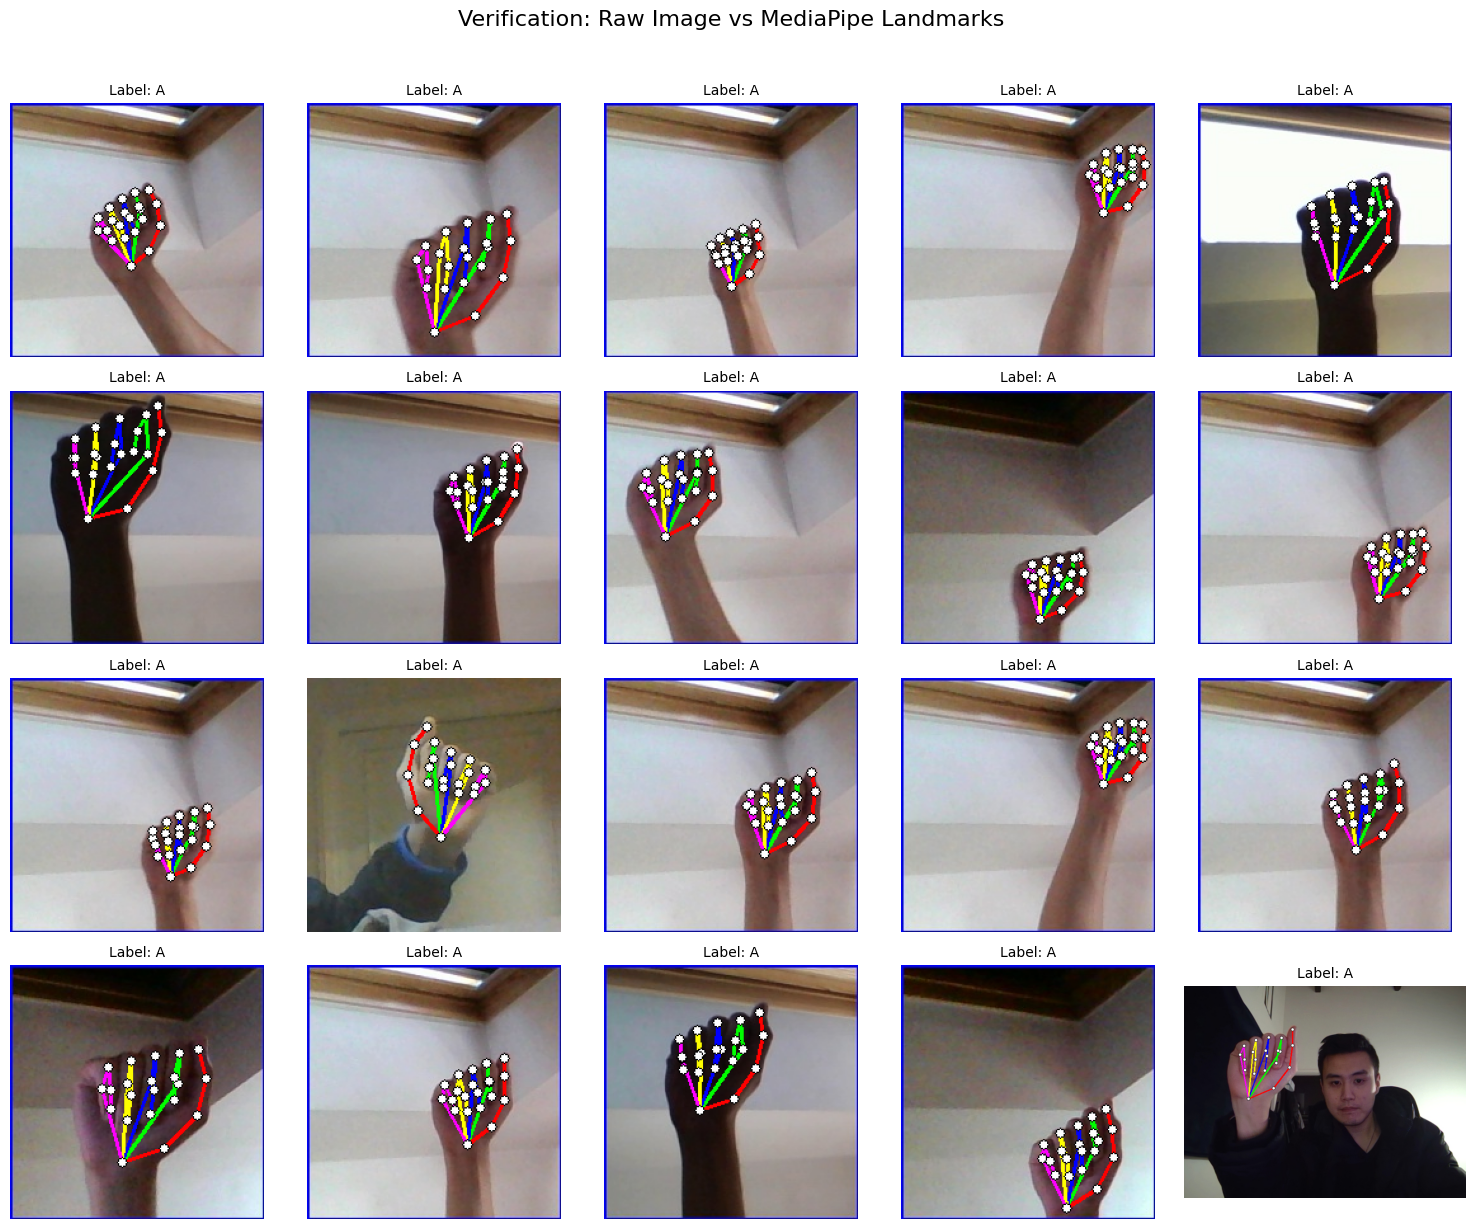

In [7]:
if 'debug_samples' in globals() and len(debug_samples) > 0:
    print(f"Kiem tra truc quan {len(debug_samples)} mau du lieu ngau nhien:")
    
    rows = 4
    cols = 5
    plt.figure(figsize=(15, 12))
    
    for idx, sample in enumerate(debug_samples):
        if idx >= 20: break
        
        # [DEBUG] In thong tin anh dang xu ly ra man hinh
        print(f"[DEBUG] Dang xu ly anh {idx + 1}/{min(len(debug_samples), 20)} - Label: {sample['label']}")
        
        # Ve landmarks len anh goc
        img_processed = draw_landmarks_on_image_new(sample['img_rgb'], sample['result'])
        
        plt.subplot(rows, cols, idx + 1)
        plt.imshow(img_processed)
        plt.title(f"Label: {sample['label']}", fontsize=10)
        plt.axis('off')
        
    plt.suptitle("Verification: Raw Image vs MediaPipe Landmarks", y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("Khong co mau de hien thi (Hay dat SKIP_PROCESSING = False de thu thap mau).")

## 2.4. Thống kê dữ liệu

Kiểm tra độ cân bằng của tập dữ liệu.

Kích thước dữ liệu đầu vào: (159623, 42)


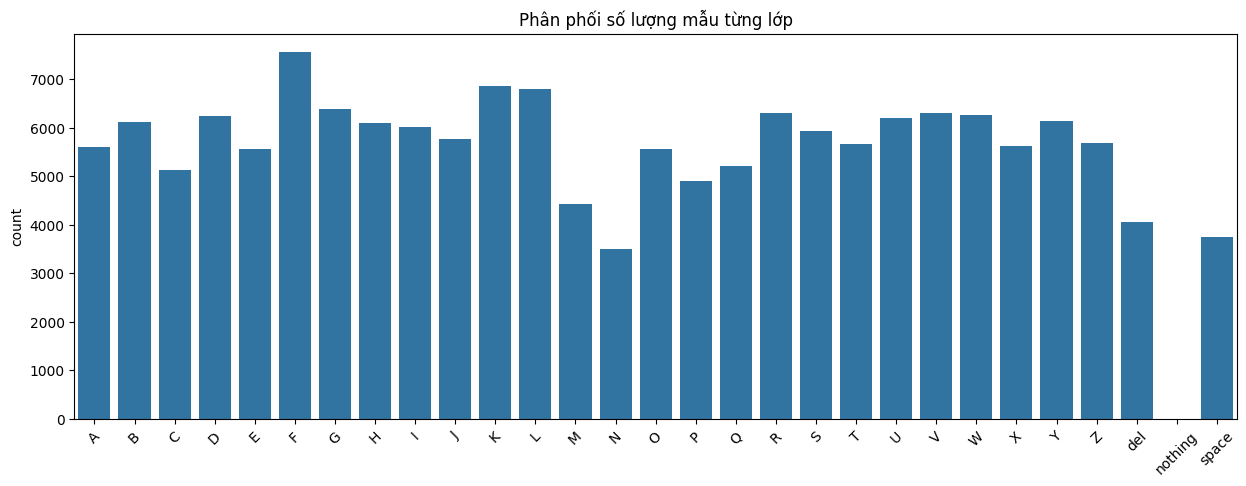

In [8]:
# Convert sang Numpy & DataFrame
data_np = np.asarray(data)
labels_np = np.asarray(labels)

print(f"Kích thước dữ liệu đầu vào: {data_np.shape}") # (Samples, 42)

plt.figure(figsize=(15, 5))
sns.countplot(x=labels, order=sorted(list(set(labels))))
plt.title('Phân phối số lượng mẫu từng lớp')
plt.xticks(rotation=45)
plt.show()

## 2.7. Lưu dữ liệu

In [9]:
import os

# Đặt tên file mới
PROCESSED_DATA_PATH = 'new_data.pickle'

if not SKIP_PROCESSING:
    print("Đang lưu file dữ liệu...")
    
    # Tạo dictionary dữ liệu
    data_to_save = {'data': data, 'labels': labels}
    
    # Lưu file
    with open(PROCESSED_DATA_PATH, 'wb') as f:
        pickle.dump(data_to_save, f)
    
    # --- KIỂM TRA THÔNG TIN FILE ---
    # 1. Kiểm tra dung lượng file
    file_size_bytes = os.path.getsize(PROCESSED_DATA_PATH)
    file_size_mb = file_size_bytes / (1024 * 1024) # Đổi sang MB
    
    print(f"Đã lưu thành công: '{PROCESSED_DATA_PATH}'")
    print(f"Dung lượng file: {file_size_mb:.2f} MB")
    
    # 2. Kiểm tra cấu trúc dữ liệu bên trong
    print("\n--- CHI TIẾT DỮ LIỆU ---")
    print(f"Các trường (Keys): {list(data_to_save.keys())}")
    print(f"'data' (Vectors): {len(data_to_save['data'])} mẫu (Đơn vị: List các vector 42 chiều)")
    print(f"'labels' (Nhãn):  {len(data_to_save['labels'])} nhãn (Đơn vị: String tên folder)")
    
    # Kiểm tra nhanh mẫu đầu tiên để đảm bảo đúng format
    if len(data) > 0:
        print(f"Ví dụ mẫu đầu tiên (Length): {len(data[0])} features")

else:
    print(f"Không cần lưu (Dữ liệu đã được load từ {PROCESSED_DATA_PATH})")

Đang lưu file dữ liệu...
Đã lưu thành công: 'new_data.pickle'
Dung lượng file: 58.92 MB

--- CHI TIẾT DỮ LIỆU ---
Các trường (Keys): ['data', 'labels']
'data' (Vectors): 159623 mẫu (Đơn vị: List các vector 42 chiều)
'labels' (Nhãn):  159623 nhãn (Đơn vị: String tên folder)
Ví dụ mẫu đầu tiên (Length): 42 features


# 3. Train Model

## 3.1. Giải thích tham số huấn luyện

Chúng ta sử dụng mạng nơ-ron nhân tạo (ANN) với các cấu hình sau:

    Epochs = 100: Số vòng lặp huấn luyện tối đa. Kết hợp với Early Stopping để dừng sớm nếu không học thêm được.

    Batch Size = 32: Số lượng mẫu được cập nhật trọng số một lần. Size nhỏ giúp mô hình thoát khỏi điểm tối ưu cục bộ tốt hơn.

    Dropout (0.3): Kỹ thuật Regularization, tắt ngẫu nhiên 30% nơ-ron trong quá trình train để ép mạng học các đặc trưng tổng quát, tránh học vẹt (Overfitting).

    Activation 'ReLU': Hàm kích hoạt phi tuyến tính chuẩn cho các lớp ẩn.

## 3.2. Chuẩn bị dữ liệu (Encoding & Splitting)

In [10]:
# Đường dẫn file dữ liệu đã xử lý (Phải khớp với Mục 2.7)
# PROCESSED_DATA_PATH = 'new_data.pickle'

print(f"Đang tải dữ liệu từ: {PROCESSED_DATA_PATH}...")

if os.path.exists(PROCESSED_DATA_PATH):
    # Load dữ liệu
    with open(PROCESSED_DATA_PATH, 'rb') as f:
        data_dict = pickle.load(f)
        
    # Chuyển sang Numpy array
    data_np = np.asarray(data_dict['data'])
    labels_raw = np.asarray(data_dict['labels'])
    
    print(f"Tải thành công! Kích thước dữ liệu: {data_np.shape}")

    # Mã hóa nhãn (String -> Integer)
    le = LabelEncoder()
    labels_encoded = le.fit_transform(labels_raw)
    num_classes = len(le.classes_)
    print(f"Số lượng lớp (Classes): {num_classes}")

    # Chia tập Train/Test (80/20)
    x_train, x_test, y_train, y_test = train_test_split(
        data_np, labels_encoded, 
        test_size=0.2, 
        shuffle=True, 
        stratify=labels_encoded, 
        random_state=42
    )

    print(f"- Train set: {x_train.shape}")
    print(f"- Test set: {x_test.shape}")

else:
    print(f"LỖI: Không tìm thấy file '{PROCESSED_DATA_PATH}'. Vui lòng chạy lại Mục 2 với SKIP_PROCESSING = False.")

Đang tải dữ liệu từ: new_data.pickle...
Tải thành công! Kích thước dữ liệu: (159623, 42)
Số lượng lớp (Classes): 29
- Train set: (127698, 42)
- Test set: (31925, 42)


## 3.3. Xây dựng & Huấn luyện mô hình

In [11]:
# Xây dựng mạng ANN
model = Sequential([
    # Input Layer (42 features) -> Hidden Layer 1
    Dense(128, input_shape=(42,), activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    # Hidden Layer 2
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    # Output Layer (Softmax cho bài toán phân loại nhiều lớp)
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

I0000 00:00:1770286863.931525      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 29)             │         1,885 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,413 (64.11 KB)

 Trainable params: 16,029 (62.61 KB)

 Non-trainable params: 384 (1.50 KB)

In [12]:
# Cấu hình Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Bắt đầu huấn luyện
history = model.fit(
    x_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(x_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100


I0000 00:00:1770286867.107551     103 service.cc:152] XLA service 0x7fce08004f00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770286867.107586     103 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1770286867.471329     103 cuda_dnn.cc:529] Loaded cuDNN version 91002


  73/3991 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.0860 - loss: 3.5992

I0000 00:00:1770286869.286819     103 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3991/3991 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.6878 - loss: 1.1412 - val_accuracy: 0.8679 - val_loss: 0.4442
Epoch 2/100
3991/3991 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8573 - loss: 0.5067 - val_accuracy: 0.8625 - val_loss: 0.4676
Epoch 3/100
3991/3991 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8727 - loss: 0.4520 - val_accuracy: 0.9095 - val_loss: 0.3123
Epoch 4/100
3991/3991 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8754 - loss: 0.4383 - val_accuracy: 0.8996 - val_loss: 0.3665
Epoch 5/100
3991/3991 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8786 - loss: 0.4272 - val_accuracy: 0.9417 - val_loss: 0.2311
Epoch 6/100
3991/3991 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8834 - loss: 0.4098 - val_accuracy: 0.9267 - val_loss: 0.2542
Epoch 7/100
3991/3991 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8859 - loss: 0.4016 - val_accuracy: 0.9395 - val_loss: 0.2305
Epoch 8/100
3991/3991 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.8916 - loss: 0.385

## 3.4. Đánh giá & Lưu mô hình (Dynamic Saving)

Tên file mô hình sẽ tự động bao gồm: Độ chính xác (Acc) + Ngày giờ huấn luyện.

In [13]:
from sklearn.metrics import classification_report, top_k_accuracy_score
import time

# --- 3.4. DANH GIA CHI TIET MO HINH (DETAILED EVALUATION) ---

print("=== 1. TONG QUAN HIEU SUAT (PERFORMANCE OVERVIEW) ===")

# 1.1. Danh gia tren tap Test (Final Evaluation)
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy:  {test_acc * 100:.2f}%")
print(f"Test Loss:      {test_loss:.4f}")

# 1.2. Danh gia tren tap Train (de so sanh Overfitting)
train_loss, train_acc = model.evaluate(x_train, y_train, verbose=0)
print(f"Train Accuracy: {train_acc * 100:.2f}%")

# 1.3. Kiem tra Overfitting / Underfitting
print("\n=== 2. PHAN TICH OVERFITTING/UNDERFITTING ===")
acc_gap = train_acc - test_acc

print(f"Chenh lech (Train - Test): {acc_gap * 100:.2f}%")

if train_acc < 0.70:
    print("KET LUAN: Underfitting (Mo hinh chua hoc duoc dac trung).")
    print("GIAI PHAP: Tang do phuc tap mo hinh (them layer/neuron), train lau hon.")
elif acc_gap > 0.10: # Chenh lech > 10%
    print("KET LUAN: Overfitting nang (Hoc vet du lieu Train).")
    print("GIAI PHAP: Tang Dropout, giam do phuc tap mo hinh, them du lieu.")
elif acc_gap > 0.05: # Chenh lech > 5%
    print("KET LUAN: Co dau hieu Overfitting nhe.")
    print("GIAI PHAP: Chap nhan duoc, nhung co the tang nhe Dropout.")
else:
    print("KET LUAN: Mo hinh tot (Good Fit), on dinh giua Train va Test.")

# 1.4. Do toc do du doan (Inference Speed)
print("\n=== 3. TOC DO DU DOAN (INFERENCE SPEED) ===")
start_time = time.time()
y_pred_probs = model.predict(x_test, verbose=0)
end_time = time.time()

total_time = end_time - start_time
avg_time_per_sample = (total_time / len(x_test)) * 1000 # doi sang ms

print(f"Tong thoi gian du doan {len(x_test)} mau: {total_time:.4f} giay")
print(f"Trung binh moi mau: {avg_time_per_sample:.4f} ms")

# 1.5. Top-k Accuracy (Do chinh xac trong Top 3 va Top 5)
# (Huu ich voi ASL vi co nhieu ky tu gan giong nhau nhu M, N, S)
print("\n=== 4. TOP-K ACCURACY ===")
# Lay du doan class
y_pred = np.argmax(y_pred_probs, axis=1)

top3_acc = top_k_accuracy_score(y_test, y_pred_probs, k=3)
top5_acc = top_k_accuracy_score(y_test, y_pred_probs, k=5)

print(f"Top-3 Accuracy: {top3_acc * 100:.2f}% (Xac suat dap an dung nam trong 3 du doan cao nhat)")
print(f"Top-5 Accuracy: {top5_acc * 100:.2f}% (Xac suat dap an dung nam trong 5 du doan cao nhat)")

# 1.6. Bao cao chi tiet tung lop
print("\n=== 5. BAO CAO CHI TIET (CLASSIFICATION REPORT) ===")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# --- DYNAMIC SAVING ---
print("\n=== 6. LUU MO HINH (SAVING) ===")
current_time = datetime.now().strftime("%Y%m%d_%H%M")
model_filename = f"model_acc{test_acc*100:.2f}_{current_time}.keras"

model.save(model_filename)
print(f"Da luu model: {model_filename}")

# Luu Label Encoder
with open('label_encoder.pickle', 'wb') as f:
    pickle.dump(le, f)
print("Da luu Label Encoder: label_encoder.pickle")

=== 1. TONG QUAN HIEU SUAT (PERFORMANCE OVERVIEW) ===
Test Accuracy:  95.33%
Test Loss:      0.1688
Train Accuracy: 95.52%

=== 2. PHAN TICH OVERFITTING/UNDERFITTING ===
Chenh lech (Train - Test): 0.19%
KET LUAN: Mo hinh tot (Good Fit), on dinh giua Train va Test.

=== 3. TOC DO DU DOAN (INFERENCE SPEED) ===
Tong thoi gian du doan 31925 mau: 2.2338 giay
Trung binh moi mau: 0.0700 ms

=== 4. TOP-K ACCURACY ===
Top-3 Accuracy: 98.66% (Xac suat dap an dung nam trong 3 du doan cao nhat)
Top-5 Accuracy: 99.27% (Xac suat dap an dung nam trong 5 du doan cao nhat)

=== 5. BAO CAO CHI TIET (CLASSIFICATION REPORT) ===
              precision    recall  f1-score   support

           A       0.93      0.98      0.95      1122
           B       0.95      1.00      0.97      1225
           C       0.95      0.95      0.95      1027
           D       0.98      0.92      0.95      1246
           E       0.92      0.97      0.95      1113
           F       0.95      0.98      0.97      1511
     

## 3.5. Biểu đồ Learning Curve & Confusion Matrix

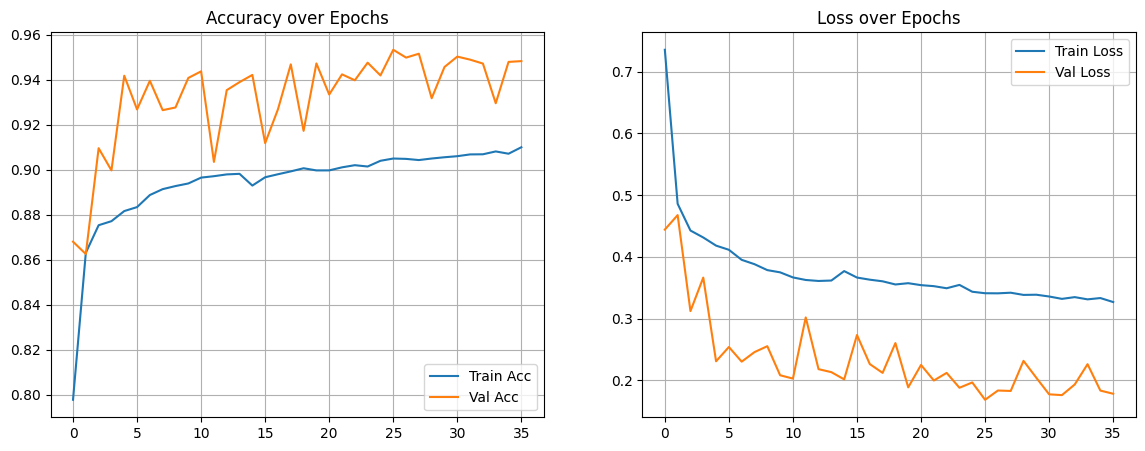

998/998 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


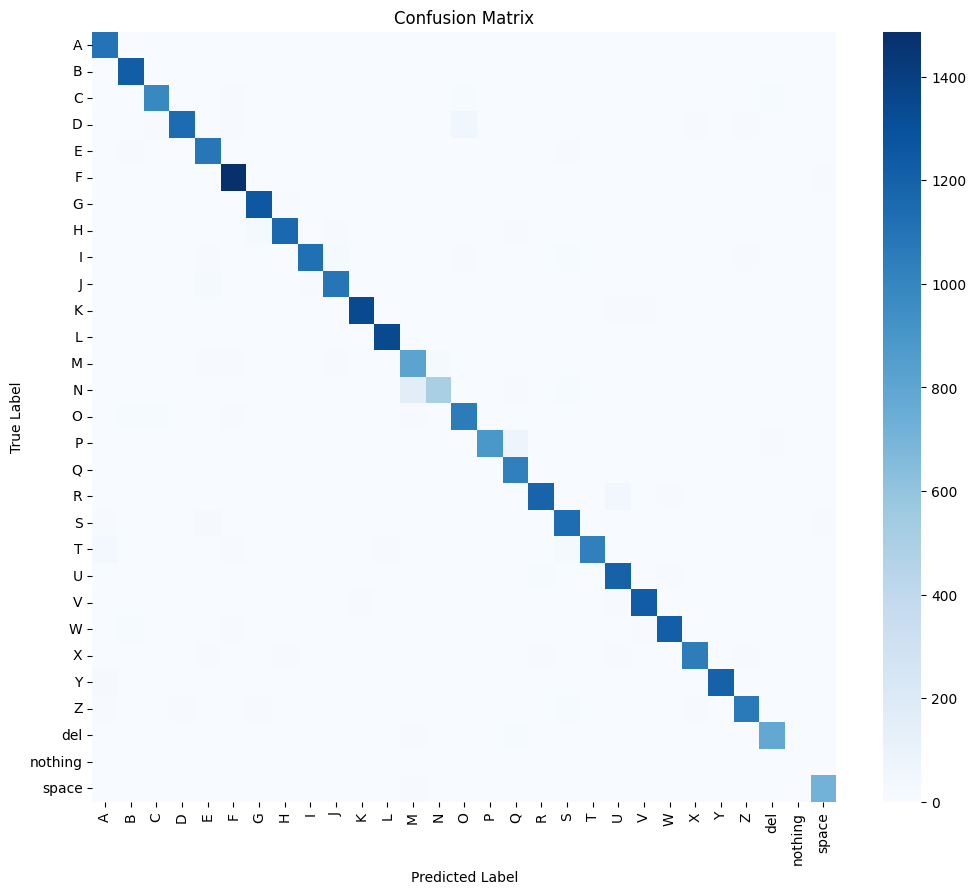

In [14]:
# Vẽ Learning Curve
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy over Epochs')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

# Vẽ Confusion Matrix
y_pred_prob = model.predict(x_test)
y_pred = np.argmax(y_pred_prob, axis=1)

plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# 4. Test Model (Inference)

4.1. Giải thích tham số Test

Khi chạy thực tế trên tập Test (dữ liệu chưa từng thấy), ta cần điều chỉnh:

    min_hand_detection_confidence = 0.3: Dữ liệu thực tế thường nhiễu hơn training. Hạ ngưỡng này xuống 0.3 giúp tăng khả năng bắt được tay (Recall), tránh bỏ sót.

    c_score (Confidence Score): Hiển thị độ tự tin của mô hình với dự đoán đó (ví dụ: Chắc chắn 99% đây là chữ A).

## 4.2. Chạy Dự đoán (Inference Loop)

Đoạn code này thực hiện đầy đủ quy trình: Đọc ảnh -> Detect Landmarks -> Chuẩn hóa bounding box -> Predict -> Visualize kết quả.

W0000 00:00:1770287264.502206    1098 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1770287264.523787    1099 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Bắt đầu dự đoán...
Hand not detected in: A_test.jpg


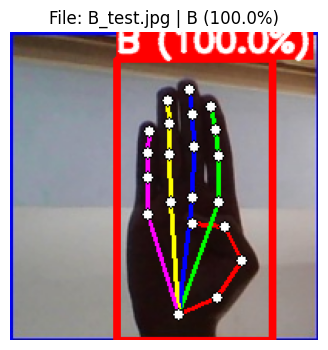

Hand not detected in: C_test.jpg
Hand not detected in: D_test.jpg
Hand not detected in: E_test.jpg


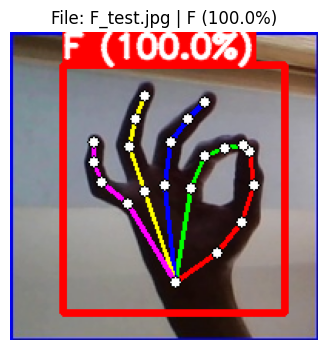

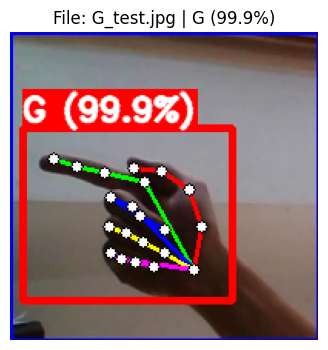

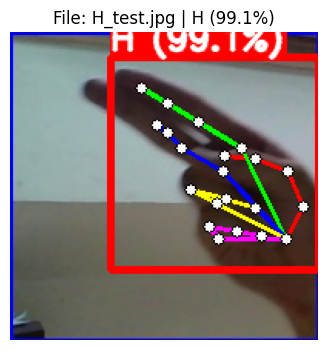

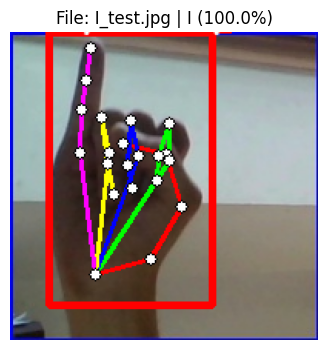

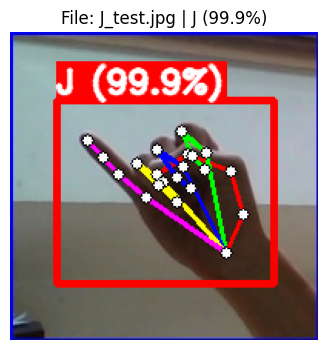

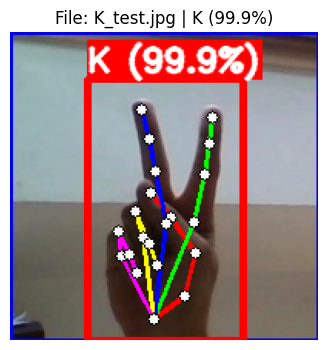

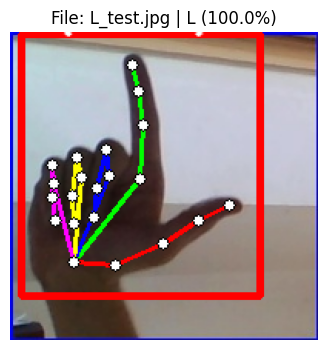

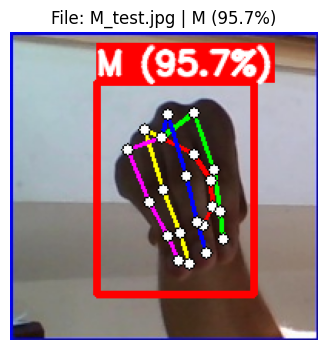

Hand not detected in: N_test.jpg


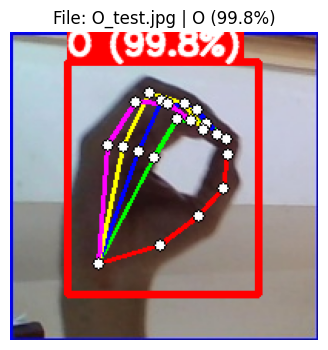

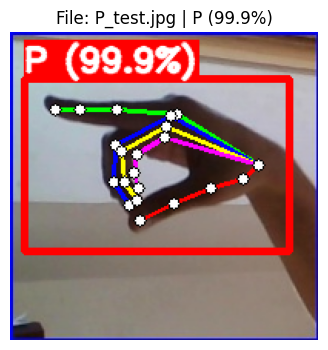

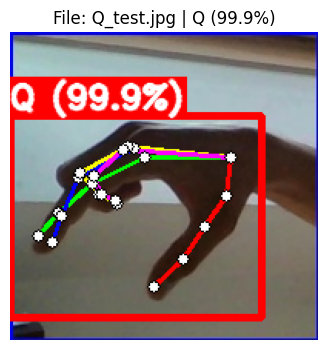

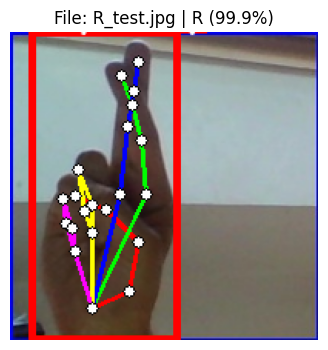

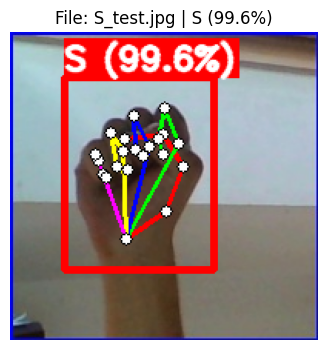

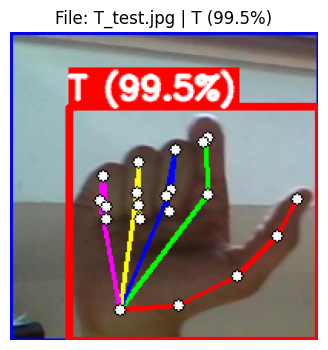

Hand not detected in: U_test.jpg
Hand not detected in: V_test.jpg


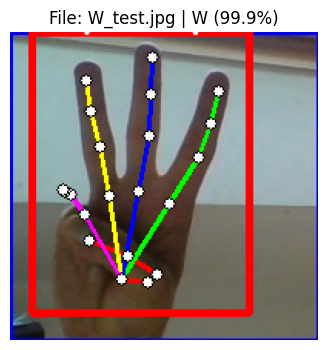

Hand not detected in: X_test.jpg


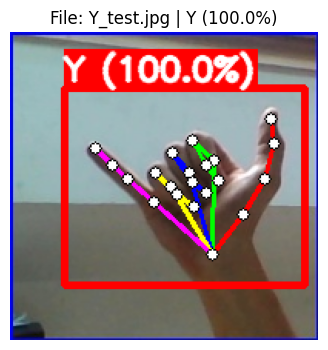

Hand not detected in: Z_test.jpg
Hand not detected in: nothing_test.jpg


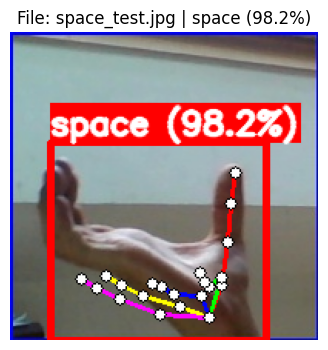

In [15]:
# Load Model & Encoder
model = load_model(model_filename) # Load file vừa train xong
with open('label_encoder.pickle', 'rb') as f:
    le = pickle.load(f)

# Cấu hình Detector cho Test
base_options = python.BaseOptions(model_asset_path='hand_landmarker.task')
options = vision.HandLandmarkerOptions(
    base_options=base_options,
    num_hands=1,
    min_hand_detection_confidence=0.3 # Ngưỡng thấp cho tập test khó
)
detector = vision.HandLandmarker.create_from_options(options)

TEST_DIR = '/kaggle/input/aslamerican-sign-language-aplhabet-dataset/ASL_Alphabet_Dataset/asl_alphabet_test'
test_images = sorted([f for f in os.listdir(TEST_DIR) if f.endswith('.jpg')])

print("Bắt đầu dự đoán...")

for img_name in test_images:
    img_path = os.path.join(TEST_DIR, img_name)
    frame = cv2.imread(img_path)
    if frame is None: continue
        
    H, W, _ = frame.shape
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
    
    detection_result = detector.detect(mp_image)

    if detection_result.hand_landmarks:
        hand_landmarks = detection_result.hand_landmarks[0]
        data_aux = []
        x_coords = []
        y_coords = []
        
        for landmark in hand_landmarks:
            data_aux.extend([landmark.x, landmark.y])
            x_coords.append(landmark.x)
            y_coords.append(landmark.y)

        # Tính toán Bounding Box
        x1 = int(min(x_coords) * W) - 20
        y1 = int(min(y_coords) * H) - 20
        x2 = int(max(x_coords) * W) + 20
        y2 = int(max(y_coords) * H) + 20
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(W, x2), min(H, y2)

        if len(data_aux) == 42:
            # Predict
            pred_prob = model.predict([np.asarray(data_aux).reshape(1, -1)], verbose=0)
            pred_idx = np.argmax(pred_prob)
            c_score = np.max(pred_prob)
            pred_char = le.inverse_transform([pred_idx])[0]
            
            # --- VISUALIZATION ---
            # 1. Vẽ Landmarks (màu custom)
            annotated_rgb = draw_landmarks_on_image_new(frame_rgb, detection_result)
            frame_final = cv2.cvtColor(annotated_rgb, cv2.COLOR_RGB2BGR)

            # 2. Vẽ Bounding Box ĐỎ
            cv2.rectangle(frame_final, (x1, y1), (x2, y2), (0, 0, 255), 3)
            
            # 3. Hiển thị Text + Score
            label_text = f"{pred_char} ({c_score*100:.1f}%)"
            (w_text, h_text), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
            cv2.rectangle(frame_final, (x1, y1 - 25), (x1 + w_text, y1), (0, 0, 255), -1)
            cv2.putText(frame_final, label_text, (x1, y1 - 5), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2, cv2.LINE_AA)

            plt.figure(figsize=(4, 4))
            plt.imshow(cv2.cvtColor(frame_final, cv2.COLOR_BGR2RGB))
            plt.title(f"File: {img_name} | {label_text}")
            plt.axis('off')
            plt.show()
    else:
        print(f"Hand not detected in: {img_name}")

detector.close()

<!-- * GÓP Ý TỪ M.A.S -->

<!-- * thêm thời process
* thêm visualize data trước process và sau process
* được phân tích sâu vào về ma trận hoặc vetor
* phân phối giữa các nhãn là gì chưa vẽ ra -->

<!-- * giải thích tại sao lại dùng mô hình này, tại sao không dùng deep learning.
* cho ra metric đánh giá, giải thích tại sao bài toán này lại dùng metric này.
* giả sử rf mô hình tốt nhất( đã được giải thích ở câu đầu) thì tại sao lại để n_e=100, tại sao kh điều chỉnh các tham số khác trong mô hình.
* vẽ thêm các biểu đồ đánh giá xem mô hình có bị overfit không -->